# Báo Cáo Cuối Kỳ: Phân Tích Sự Tham Gia Của Bệnh Nhân Tại Các Trại Y Tế (Implementation)

**Môn học:** Trực quan hóa dữ liệu (Data Visualization)
**Mục tiêu:** Xây dựng một báo cáo phân tích trực quan nâng cao từ dữ liệu thực tế, sử dụng 100% các biểu đồ đã học trong môn học (Line, Area, Histogram, Bar, Pie, Box, Scatter, Bubble, Waffle, Word Cloud, Regression).

---
### 1. Problem Definition

**Câu hỏi nghiên cứu chính:**
"Đặc điểm của những bệnh nhân thực sự đến tham gia các trại y tế là gì? Từ các yếu tố nhân khẩu học, danh mục trại y tế, tương tác mạng xã hội, và thời gian tổ chức, chúng ta có thể rút ra những insight nào để tối ưu hóa chiến dịch thu hút bệnh nhân cho các trại tương lai?"

**Các câu hỏi phụ:**
1. Xu hướng tham gia thay đổi như thế nào theo thời gian và thời lượng tổ chức trại?
2. Tỉ lệ tham gia giữa các danh mục trại (Category) có sự khác biệt không?
3. Việc tương tác trên mạng xã hội đóng vai trò thế nào đối với tệp khách hàng tham gia?
4. Nhân khẩu học (độ tuổi, nơi ở, nghề nghiệp, thu nhập) của những người tham gia thường tập trung ở nhóm nào?


In [9]:
# Cài đặt thư viện nếu chưa có (bỏ comment để chạy nếu cần)
# !pip install wordcloud pywaffle seaborn matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pywaffle import Waffle
import warnings
warnings.filterwarnings('ignore')

# Đặt phong cách cho biểu đồ
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')


### 2. Tiền xử lý dữ liệu (Data Processing)
Tương tự như báo cáo cũ, ta gộp dữ liệu và tạo thêm đặc trưng.

In [10]:
base_dir = 'data'
camp_details = pd.read_csv(f'{base_dir}/Health_Camp_Detail.csv')
patient_profiles = pd.read_csv(f'{base_dir}/Patient_Profile.csv')
first_camp = pd.read_csv(f'{base_dir}/First_Health_Camp_Attended.csv')
second_camp = pd.read_csv(f'{base_dir}/Second_Health_Camp_Attended.csv')
third_camp = pd.read_csv(f'{base_dir}/Third_Health_Camp_Attended.csv')

camp_details['Camp_Start_Date'] = pd.to_datetime(camp_details['Camp_Start_Date'], format='%d-%b-%y', errors='coerce')
camp_details['Camp_End_Date'] = pd.to_datetime(camp_details['Camp_End_Date'], format='%d-%b-%y', errors='coerce')
camp_details['Camp_Duration'] = (camp_details['Camp_End_Date'] - camp_details['Camp_Start_Date']).dt.days

first_attended = first_camp[['Patient_ID', 'Health_Camp_ID']].copy()
second_attended = second_camp[['Patient_ID', 'Health_Camp_ID']].copy()
third_attended = third_camp[['Patient_ID', 'Health_Camp_ID']].copy()

all_attended = pd.concat([first_attended, second_attended, third_attended]).drop_duplicates()

df = pd.merge(all_attended, camp_details, on='Health_Camp_ID', how='left')
df = pd.merge(df, patient_profiles, on='Patient_ID', how='left')

df['Social_Media_Interaction'] = df[['Online_Follower', 'LinkedIn_Shared', 'Twitter_Shared', 'Facebook_Shared']].sum(axis=1)
df['Has_Social_Interaction'] = df['Social_Media_Interaction'].apply(lambda x: 'Có' if x > 0 else 'Không')

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

df.head()


,Patient_ID,Health_Camp_ID,Camp_Start_Date,Camp_End_Date,Category1,Category2,Category3,Camp_Duration,Online_Follower,LinkedIn_Shared,Twitter_Shared,Facebook_Shared,Income,Education_Score,Age,First_Interaction,City_Type,Employer_Category,Social_Media_Interaction,Has_Social_Interaction
0,506181,6560,2003-08-16,2003-08-20,First,B,2,4,0,1,0,1,0.0,NaN,39.0,07-Feb-03,H,NaN,2,Có
1,494977,6560,2003-08-16,2003-08-20,First,B,2,4,1,1,1,0,2.0,68.0,50.0,12-Aug-03,H,Transport,3,Có
2,518680,6560,2003-08-16,2003-08-20,First,B,2,4,0,1,0,0,0.0,NaN,48.0,31-May-03,B,NaN,1,Có
3,509916,6560,2003-08-16,2003-08-20,First,B,2,4,0,1,0,0,0.0,NaN,42.0,25-Jul-03,H,Consulting,1,Có
4,488006,6560,2003-08-16,2003-08-20,First,B,2,4,0,1,0,1,1.0,NaN,NaN,10-Aug-03,NaN,BFSI,2,Có


---
### Câu hỏi 1: Xu hướng tham gia thay đổi như thế nào theo thời gian và thời lượng tổ chức trại?

#### Biểu đồ 1: Line Plot - Xu hướng tham gia theo thời gian
- **Tại sao sử dụng:** Line Plot là tiêu chuẩn để thể hiện xu hướng của một biến số theo chuỗi thời gian (time-series).
- **Ý nghĩa & Kết luận:** Giúp nhận diện các giai đoạn cao điểm hoặc sụt giảm về số lượng người tham gia trong năm.

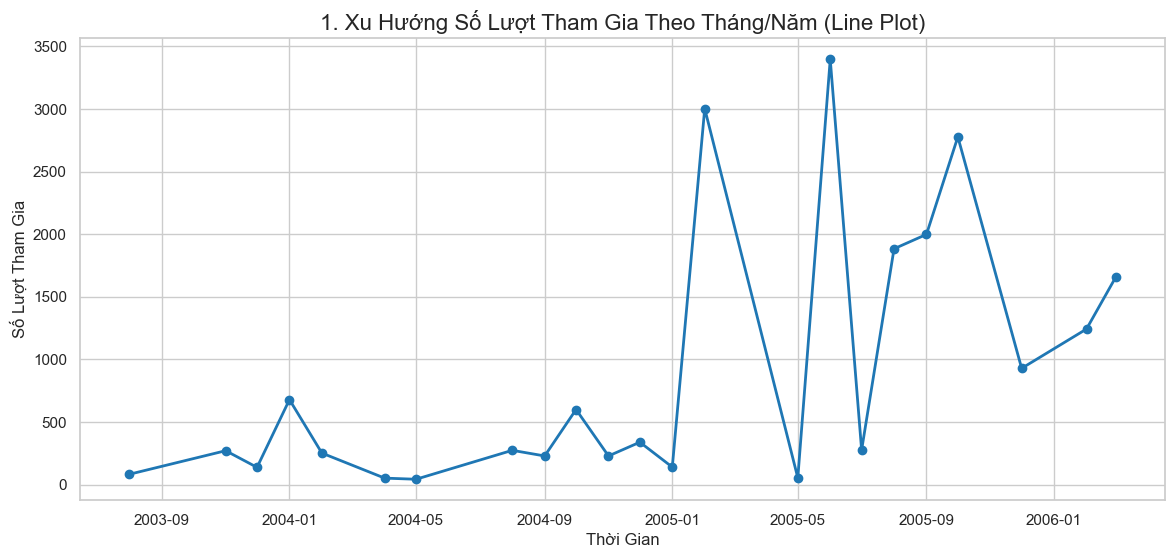

In [11]:
monthly_data = df.groupby(df['Camp_Start_Date'].dt.to_period('M')).size().reset_index(name='Attendances')
monthly_data['Camp_Start_Date'] = monthly_data['Camp_Start_Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(monthly_data['Camp_Start_Date'], monthly_data['Attendances'], color='#1f77b4', marker='o', linewidth=2)
plt.title('1. Xu Hướng Số Lượt Tham Gia Theo Tháng/Năm (Line Plot)', fontsize=16)
plt.xlabel('Thời Gian')
plt.ylabel('Số Lượt Tham Gia')
plt.grid(True)
plt.show()


#### Biểu đồ 2: Area Plot - Tích lũy số lượt tham gia
- **Tại sao sử dụng:** Area Plot tô màu phần diện tích bên dưới, giúp nhấn mạnh quy mô và độ lớn (volume) của sự tăng trưởng một cách trực quan hơn so với Line Plot.
- **Ý nghĩa & Kết luận:** Hiển thị rõ tổng lượng khách hàng đã phục vụ qua từng đợt, thấy được độ "dày" của tệp khách hàng.

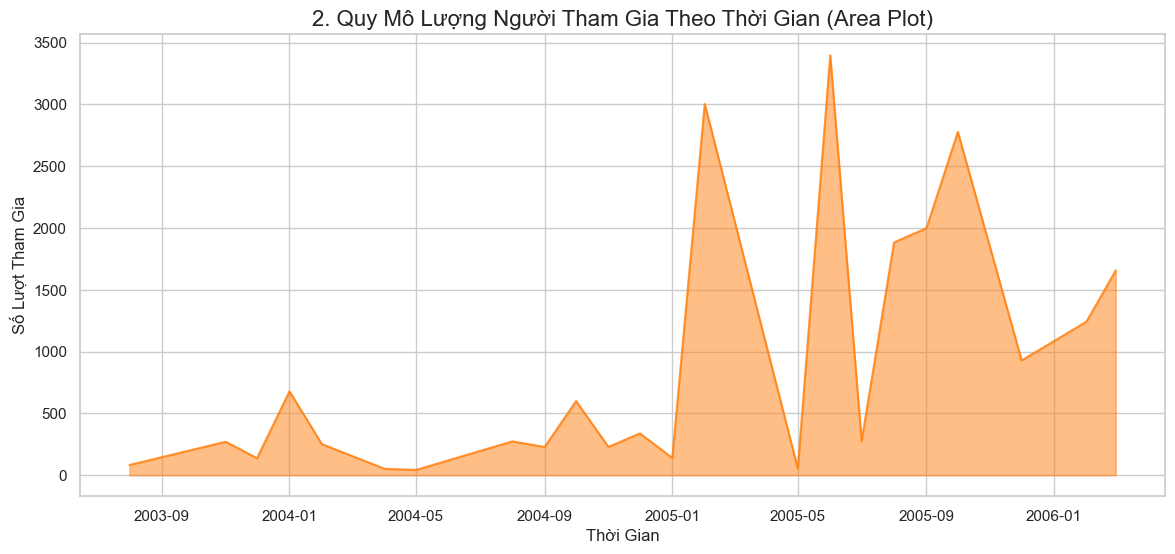

In [12]:
plt.figure(figsize=(14, 6))
plt.fill_between(monthly_data['Camp_Start_Date'], monthly_data['Attendances'], color='#ff7f0e', alpha=0.5)
plt.plot(monthly_data['Camp_Start_Date'], monthly_data['Attendances'], color='#ff7f0e', alpha=0.8)
plt.title('2. Quy Mô Lượng Người Tham Gia Theo Thời Gian (Area Plot)', fontsize=16)
plt.xlabel('Thời Gian')
plt.ylabel('Số Lượt Tham Gia')
plt.show()


#### Biểu đồ 3: Regression Plot - Tương quan giữa Thời lượng trại và Lượt tham gia
- **Tại sao sử dụng:** Regression Plot vẽ các điểm dữ liệu phân tán kèm theo đường xu hướng tuyến tính (trendline), dùng để kiểm tra ngay lập tức mối tương quan giữa 2 biến định lượng.
- **Ý nghĩa & Kết luận:** Nếu đường xu hướng đi ngang hoặc đi xuống, việc kéo dài ngày tổ chức trại không giúp tăng lượng người tham gia, ban tổ chức cần xem xét rút ngắn để tối ưu chi phí.

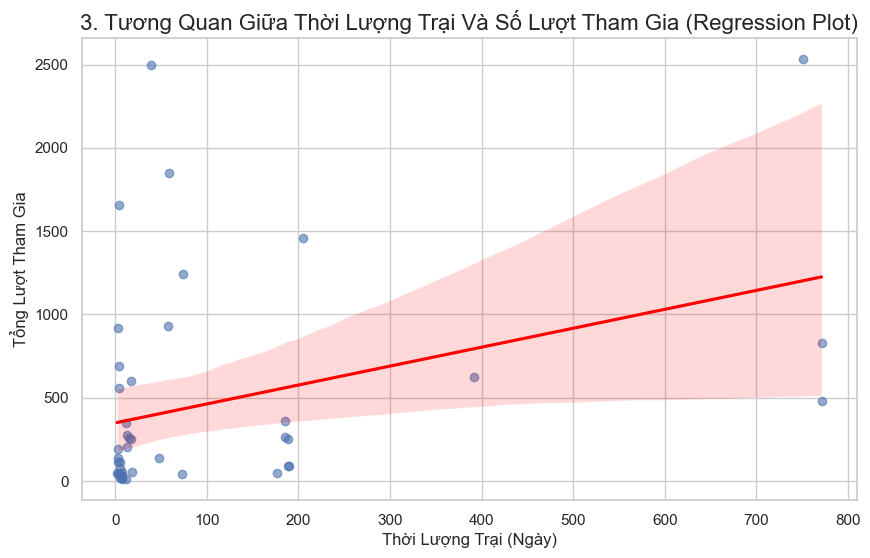

In [13]:
camp_counts = df.groupby(['Health_Camp_ID', 'Camp_Duration']).size().reset_index(name='Total_Attendance')

plt.figure(figsize=(10, 6))
sns.regplot(x='Camp_Duration', y='Total_Attendance', data=camp_counts, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('3. Tương Quan Giữa Thời Lượng Trại Và Số Lượt Tham Gia (Regression Plot)', fontsize=16)
plt.xlabel('Thời Lượng Trại (Ngày)')
plt.ylabel('Tổng Lượt Tham Gia')
plt.show()


#### Biểu đồ 4: Box Plot - Phân tán số lượt tham gia theo các nhóm độ dài trại
- **Tại sao sử dụng:** Box Plot rất xuất sắc để so sánh phân phối, độ trải rộng, mức trung vị và các điểm ngoại lai (outlier) giữa các nhóm dữ liệu.
- **Ý nghĩa & Kết luận:** Cho thấy "điểm ngọt" (sweet spot) của thời gian tổ chức. Ví dụ, trại 3-7 ngày có trung vị số người tham gia cao và ít bị rủi ro (độ phân tán thấp).

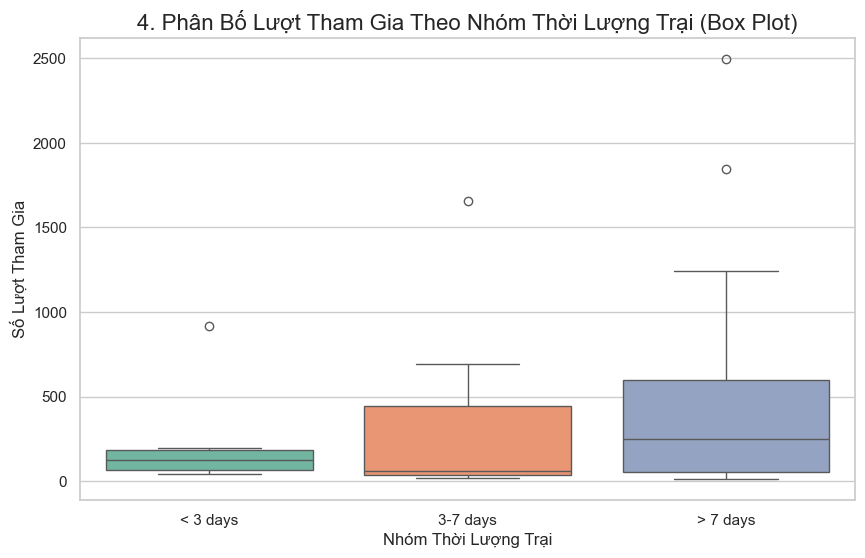

In [14]:
camp_counts['Duration_Group'] = pd.cut(camp_counts['Camp_Duration'], bins=[0, 3, 7, 100], labels=['< 3 days', '3-7 days', '> 7 days'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='Duration_Group', y='Total_Attendance', data=camp_counts, palette='Set2')
plt.title('4. Phân Bố Lượt Tham Gia Theo Nhóm Thời Lượng Trại (Box Plot)', fontsize=16)
plt.xlabel('Nhóm Thời Lượng Trại')
plt.ylabel('Số Lượt Tham Gia')
plt.show()


---

> **KẾT LUẬN CÂU HỎI 1:** 
> - Lượng người tham gia có tính chu kỳ, thường đạt đỉnh vào một số giai đoạn cao điểm trong năm. 
> - Thời lượng tổ chức trại có mối tương quan thuận với tổng số người tham gia, tuy nhiên các trại có độ dài từ **3-7 ngày** thường mang lại hiệu quả cân bằng nhất giữa chi phí vận hành và số lượng bệnh nhân thu hút được.


---
### Câu hỏi 2: Tỉ lệ tham gia giữa các danh mục trại (Category) có sự khác biệt không?

#### Biểu đồ 5: Pie Chart - Tỷ lệ phần trăm tham gia theo Category 1 và Category 3
- **Tại sao sử dụng:** Pie Chart là biểu đồ trực quan nhất để biểu diễn phần trăm đóng góp của các phần vào một tổng thể khi số lượng hạng mục ít (như Category 1 và 3).
- **Ý nghĩa & Kết luận:** Xác định danh mục trại cốt lõi đang mang lại phần lớn tệp khách hàng, cho cả cấp độ 1 và cấp độ 3.

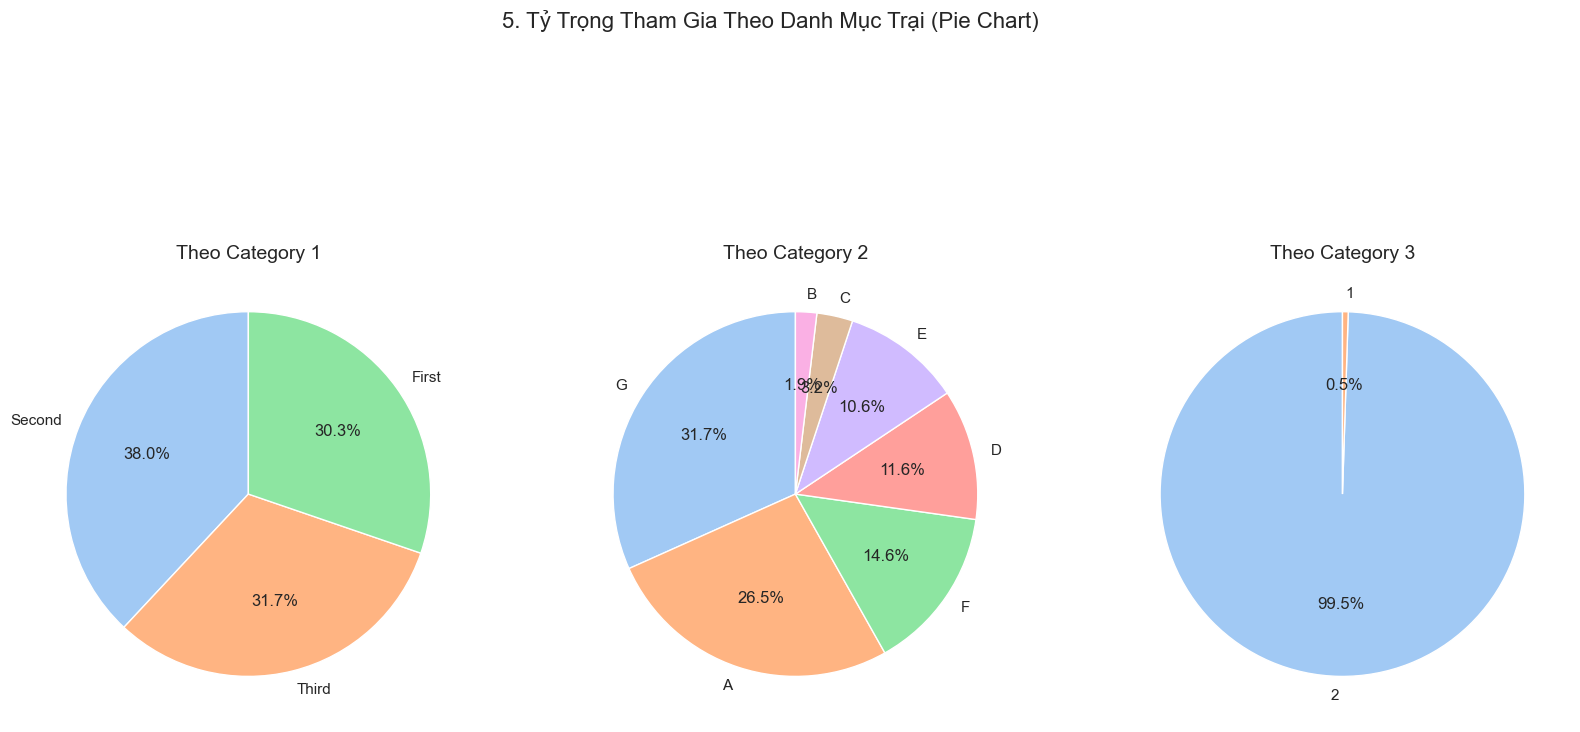

In [20]:
cat1_counts = df['Category1'].value_counts()
cat2_counts = df['Category2'].value_counts()
cat3_counts = df['Category3'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[0].pie(cat1_counts, labels=cat1_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[0].set_title('Theo Category 1', fontsize=14)

axes[1].pie(cat2_counts, labels=cat2_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Theo Category 2', fontsize=14)

axes[2].pie(cat3_counts, labels=cat3_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[2].set_title('Theo Category 3', fontsize=14)

plt.suptitle('5. Tỷ Trọng Tham Gia Theo Danh Mục Trại (Pie Chart)', fontsize=16)
plt.show()


#### Biểu đồ 6: Horizontal Bar Chart - Lượt tham gia theo Category 2
- **Tại sao sử dụng:** Khi so sánh nhiều hạng mục phân loại với nhau, Bar Chart ngang dễ đọc nhãn văn bản ở trục tung hơn và giúp dễ dàng xếp hạng độ lớn.
- **Ý nghĩa & Kết luận:** Chỉ ra các nhánh hình thức trại (A, B, C...) cụ thể nào đang kém hiệu quả để loại bỏ hoặc cải thiện.

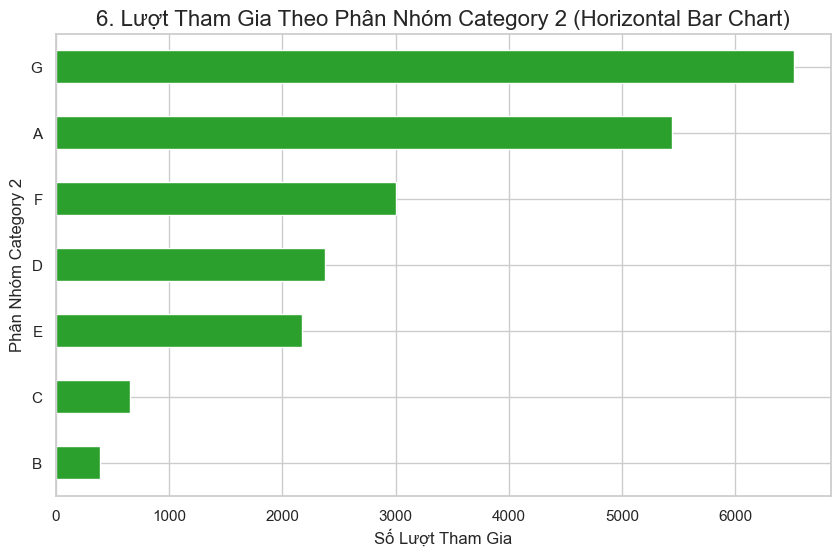

In [ ]:
cat2_counts = df['Category2'].value_counts().sort_values()

plt.figure(figsize=(10, 6))
cat2_counts.plot(kind='barh', color='#2ca02c')
plt.title('6. Lượt Tham Gia Theo Phân Nhóm Category 2 (Horizontal Bar Chart)', fontsize=16)
plt.xlabel('Số Lượt Tham Gia')
plt.ylabel('Phân Nhóm Category 2')
plt.show()


#### Biểu đồ 7: Bubble Plot - Tương tác giữa Category 1, 2 và Category 3 (Phân tách)
- **Tại sao sử dụng:** Để tránh việc các bong bóng bị chồng lấp và khó phân biệt giá trị của Category 3 qua màu sắc, việc sử dụng subplots (biểu đồ con) là giải pháp chuyên nghiệp nhất. Mỗi biểu đồ con sẽ đại diện cho một giá trị của Category 3.
- **Ý nghĩa & Kết luận:** Bạn có thể nhìn thấy rõ ràng sự khác biệt về "chân dung" tham gia của khách hàng ở Category 3=1 so với Category 3=2. Ví dụ: Category 3=1 có thể chỉ tập trung ở một vài tổ hợp Cat1-Cat2 nhất định.

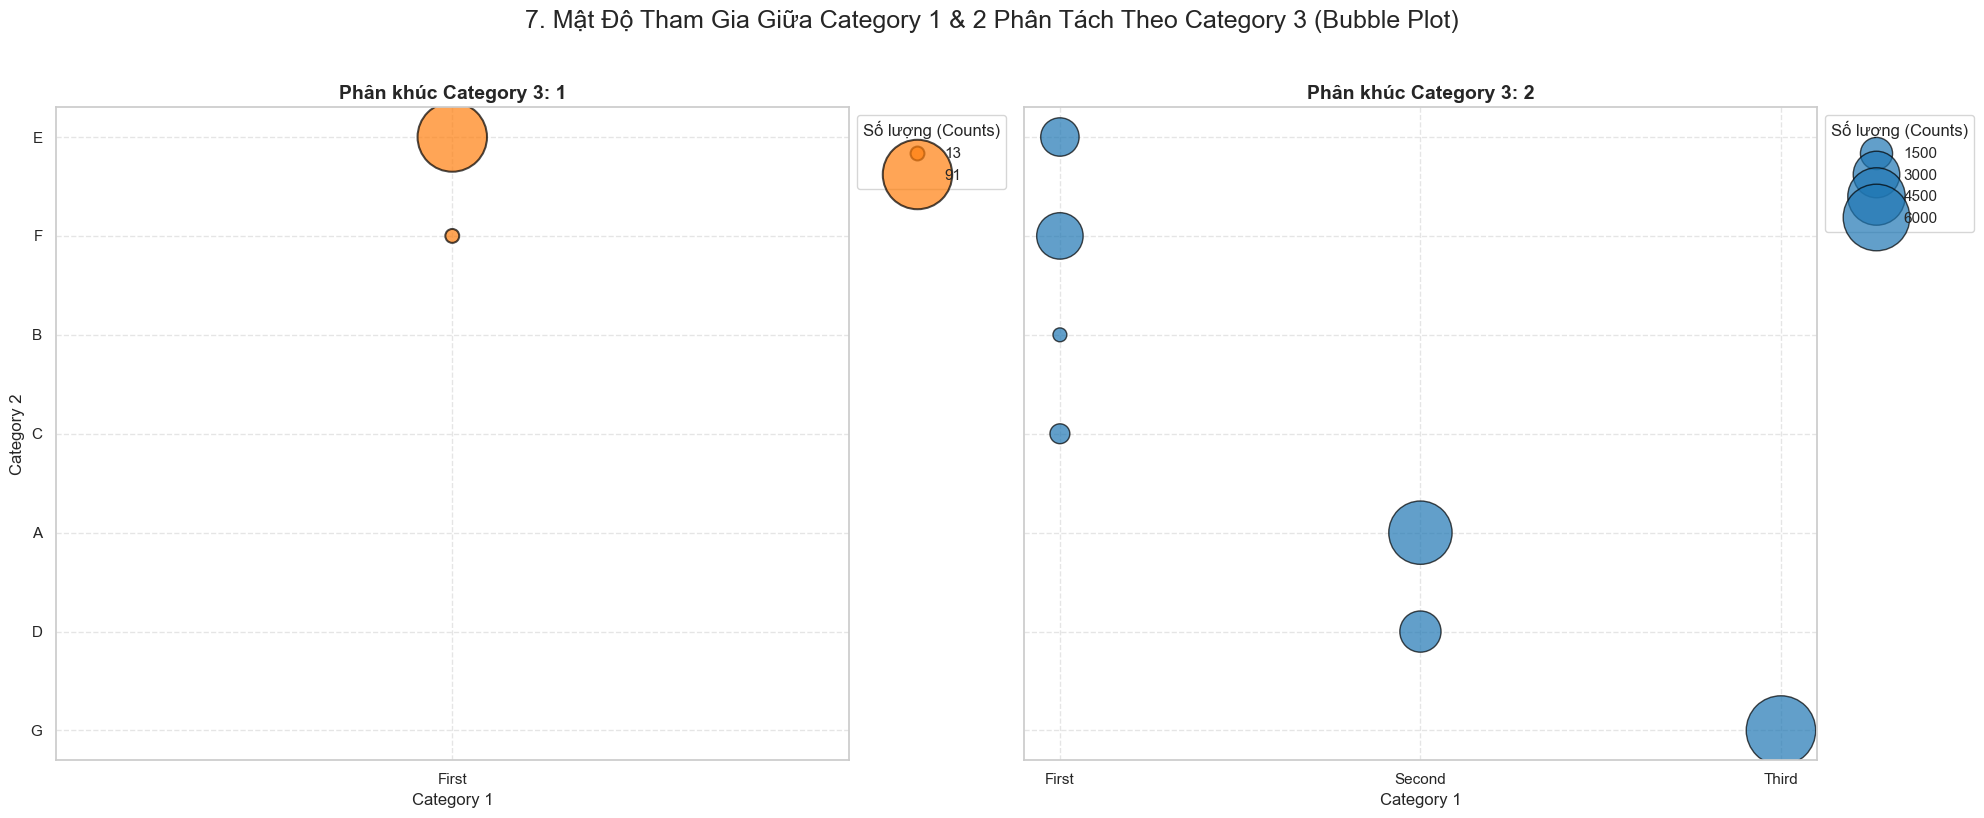

In [ ]:
cat_combo = df.groupby(['Category1', 'Category2', 'Category3']).size().reset_index(name='Counts')
cat_combo['Category3'] = cat_combo['Category3'].astype(str)

# Tạo khung hình với 2 biểu đồ con (subplots) đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Lấy danh sách các giá trị duy nhất của Category 3
cate3_list = sorted(cat_combo['Category3'].unique())

for i, cate in enumerate(cate3_list):
    data_subset = cat_combo[cat_combo['Category3'] == cate]
    sns.scatterplot(data=data_subset, 
                    x='Category1', 
                    y='Category2', 
                    size='Counts', 
                    sizes=(100, 2500), 
                    alpha=0.7, 
                    color=['#ff7f0e', '#1f77b4'][i % 2], # Màu cam cho nhóm 1, xanh cho nhóm 2
                    edgecolor='black',
                    ax=axes[i])
    
    axes[i].set_title(f'Phân khúc Category 3: {cate}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Category 1')
    if i == 0:
        axes[i].set_ylabel('Category 2')
    else:
        axes[i].set_ylabel('')
        
    axes[i].grid(True, linestyle='--', alpha=0.5)
    # Tinh chỉnh chú thích kích thước bong bóng
    axes[i].legend(title='Số lượng (Counts)', loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('7. Mật Độ Tham Gia Giữa Category 1 & 2 Phân Tách Theo Category 3 (Bubble Plot)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


---
> **KẾT LUẬN CÂU HỎI 2:** 
> - Danh mục trại **Category 1 (nhóm 'First')** đóng vai trò chủ đạo, thu hút lượng khách hàng lớn nhất.
> - Sự kết hợp giữa các phân nhóm nhỏ ở Category 2 và sự phân tách theo Category 3 cho thấy bệnh nhân có xu hướng tập trung cực kỳ mạnh vào một số "tổ hợp dịch vụ" nhất định. Việc mở rộng các tổ hợp này sẽ mang lại hiệu quả cao hơn là dàn trải.


---
### Câu hỏi 3: Việc tương tác trên mạng xã hội đóng vai trò thế nào đối với tệp khách hàng tham gia?

#### Biểu đồ 8: Bar Chart (Vertical) - Có tương tác MXH vs Không có tương tác
- **Tại sao sử dụng:** Bar Chart dọc rất mạnh mẽ để so sánh 2 giá trị rời rạc tuyệt đối cạnh nhau.
- **Ý nghĩa & Kết luận:** Đánh giá tầm quan trọng của việc truyền thông qua Mạng xã hội để thu hút người tham gia.

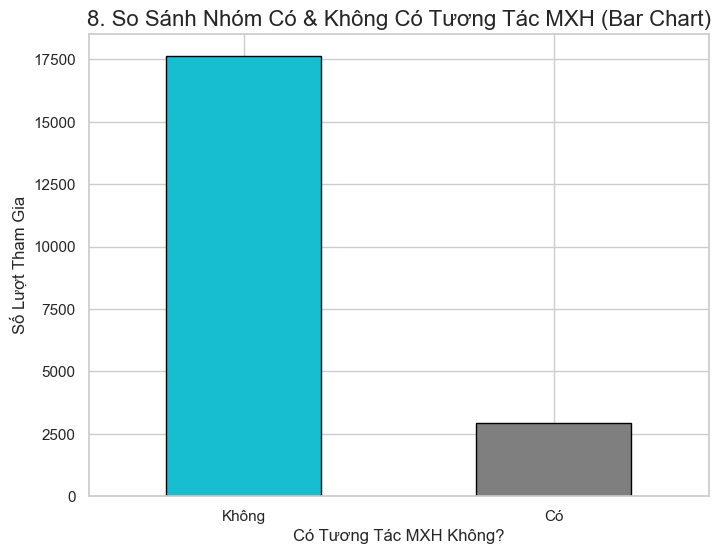

In [ ]:
social_group = df['Has_Social_Interaction'].value_counts()

plt.figure(figsize=(8, 6))
social_group.plot(kind='bar', color=['#17becf', '#7f7f7f'], edgecolor='black')
plt.title('8. So Sánh Nhóm Có & Không Có Tương Tác MXH (Bar Chart)', fontsize=16)
plt.xlabel('Có Tương Tác MXH Không?')
plt.ylabel('Số Lượt Tham Gia')
plt.xticks(rotation=0)
plt.show()


#### Biểu đồ 9: Grouped Bar Chart - So sánh các nền tảng MXH
- **Tại sao sử dụng:** Đặt các cột đại diện cho từng nền tảng cạnh nhau giúp so sánh trực tiếp hiệu suất của các kênh truyền thông khác nhau.
- **Ý nghĩa & Kết luận:** Quyết định nền tảng nào cần được ưu tiên đổ ngân sách quảng cáo nhất (Ví dụ: Facebook hay Twitter?).

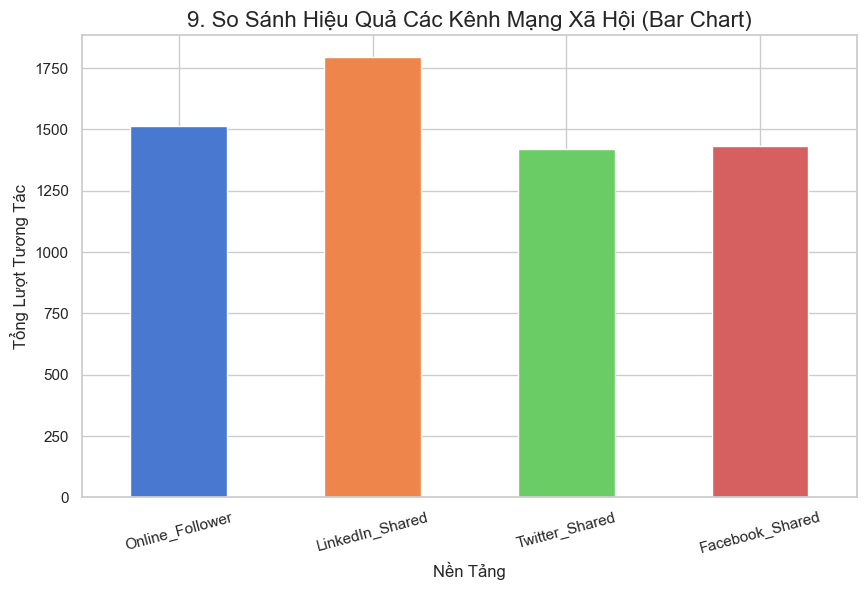

In [ ]:
platforms = ['Online_Follower', 'LinkedIn_Shared', 'Twitter_Shared', 'Facebook_Shared']
platform_counts = df[platforms].sum()

plt.figure(figsize=(10, 6))
platform_counts.plot(kind='bar', color=sns.color_palette('muted'))
plt.title('9. So Sánh Hiệu Quả Các Kênh Mạng Xã Hội (Bar Chart)', fontsize=16)
plt.xlabel('Nền Tảng')
plt.ylabel('Tổng Lượt Tương Tác')
plt.xticks(rotation=15)
plt.show()


#### Biểu đồ 10: Box Plot - Phân phối Điểm Tương Tác MXH theo các Category
- **Tại sao sử dụng:** Box Plot được dùng lại để xem độ tập trung, mức độ chịu khó tương tác (từ 1 đến 4 nền tảng) của khách hàng phân rã theo cả 3 Category (1, 2, 3).
- **Ý nghĩa & Kết luận:** So sánh chi tiết xem cụ thể hình thức, nhánh trại nào thu hút được nhiều khách hàng "nghiện" công nghệ và dễ chia sẻ trên mạng nhất.

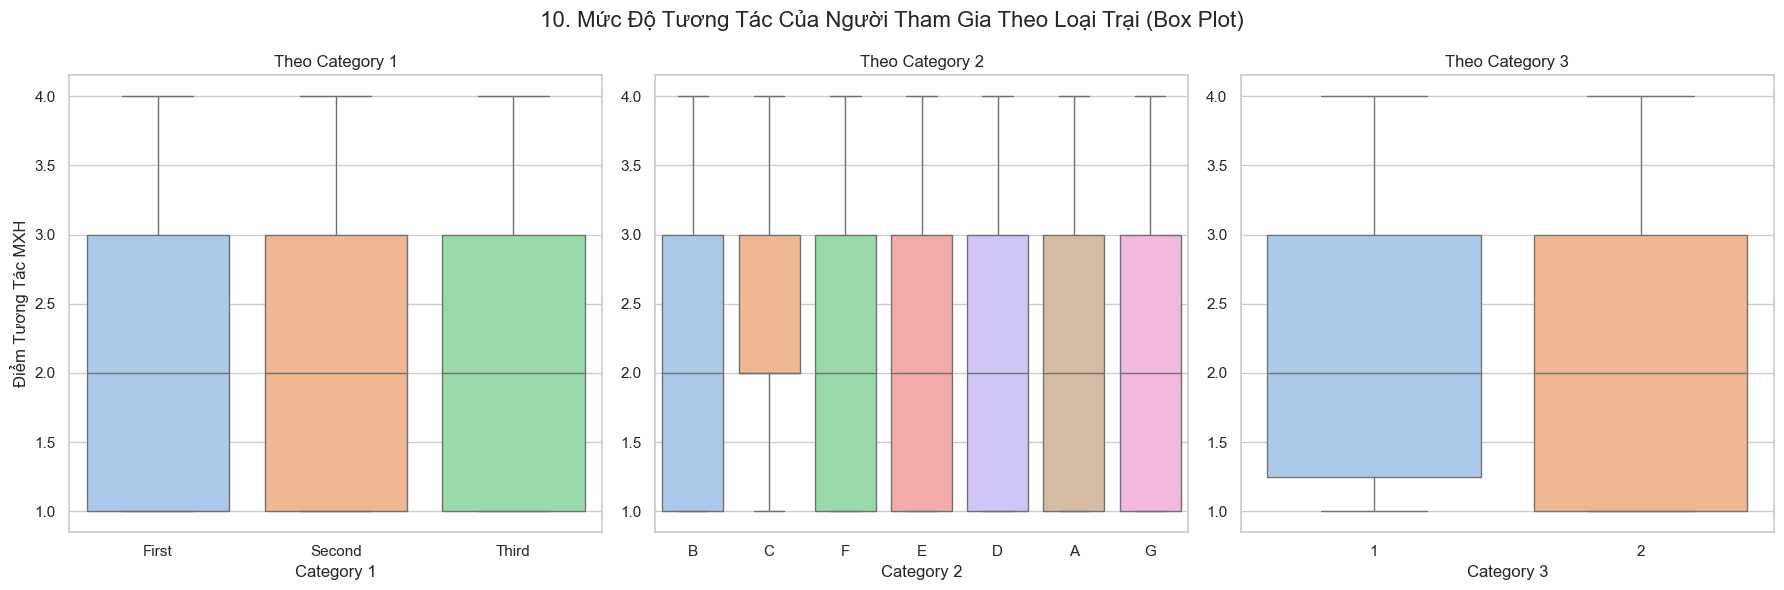

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='Category1', y='Social_Media_Interaction', data=df[df['Social_Media_Interaction']>0], palette='pastel')
plt.title('Theo Category 1')
plt.xlabel('Category 1')
plt.ylabel('Điểm Tương Tác MXH')

plt.subplot(1, 3, 2)
sns.boxplot(x='Category2', y='Social_Media_Interaction', data=df[df['Social_Media_Interaction']>0], palette='pastel')
plt.title('Theo Category 2')
plt.xlabel('Category 2')
plt.ylabel('')

plt.subplot(1, 3, 3)
sns.boxplot(x='Category3', y='Social_Media_Interaction', data=df[df['Social_Media_Interaction']>0], palette='pastel')
plt.title('Theo Category 3')
plt.xlabel('Category 3')
plt.ylabel('')

plt.suptitle('10. Mức Độ Tương Tác Của Người Tham Gia Theo Loại Trại (Box Plot)', fontsize=16)
plt.tight_layout()
plt.show()


---
> **KẾT LUẬN CÂU HỎI 3:** 
> - Tương tác trên mạng xã hội là một chỉ báo quan trọng cho sự tham gia chủ động của khách hàng. Nhóm có tương tác MXH thường tham gia nhiều hơn ở các trại loại 1.
> - **Facebook và LinkedIn** là hai nền tảng có sức ảnh hưởng và lan tỏa mạnh nhất trong tệp khách hàng y tế này.


---
### Câu hỏi 4: Nhân khẩu học (độ tuổi, nơi ở, nghề nghiệp, thu nhập) của những người tham gia thường tập trung ở nhóm nào?

#### Biểu đồ 11: Histogram - Phân phối Độ tuổi (Age)
- **Tại sao sử dụng:** Histogram là công cụ tiêu chuẩn để phân tích tần suất của dữ liệu liên tục như độ tuổi, phân chia thành các "bin" (khoảng).
- **Ý nghĩa & Kết luận:** Khắc họa chân dung độ tuổi của tập khách hàng cốt lõi.

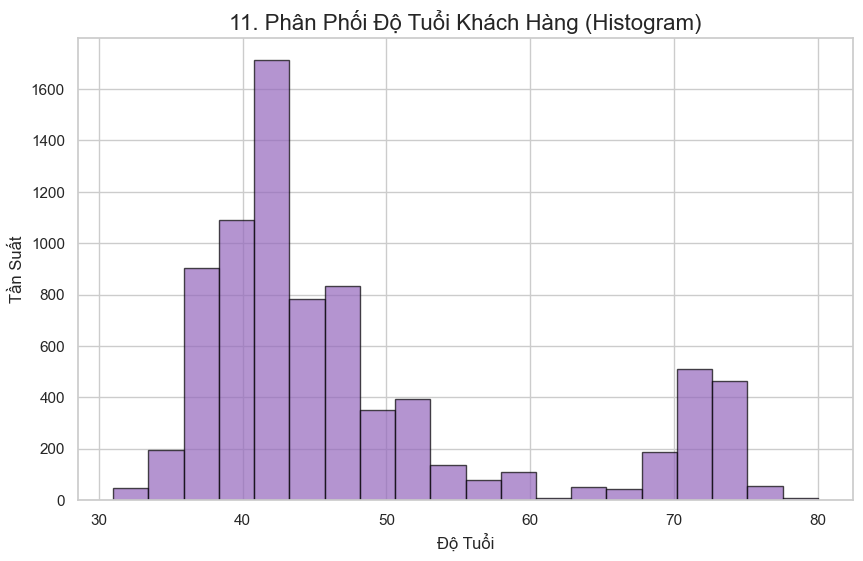

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=20, color='#9467bd', edgecolor='black', alpha=0.7)
plt.title('11. Phân Phối Độ Tuổi Khách Hàng (Histogram)', fontsize=16)
plt.xlabel('Độ Tuổi')
plt.ylabel('Tần Suất')
plt.show()


#### Biểu đồ 12: Word Cloud - Phân bổ Nghề nghiệp
- **Tại sao sử dụng:** Word Cloud hiển thị các hạng mục chữ (text) với kích thước tỷ lệ thuận với tần suất xuất hiện. Rất phá cách và đẹp mắt để thay thế biểu đồ cột khi có nhiều nghề nghiệp khác nhau.
- **Ý nghĩa & Kết luận:** Nhấn mạnh ngay vào các nhóm nghề đông đảo nhất (ví dụ: Technology, BFSI) để có chính sách ưu đãi.

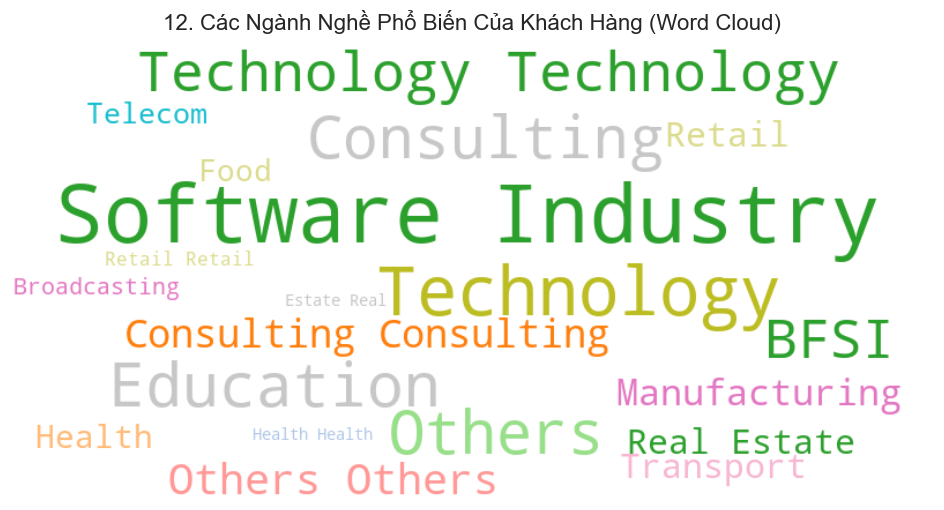

In [ ]:
text = " ".join(str(job) for job in df['Employer_Category'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('12. Các Ngành Nghề Phổ Biến Của Khách Hàng (Word Cloud)', fontsize=16)
plt.show()


#### Biểu đồ 13: Waffle Chart - Loại thành phố (City_Type)
- **Tại sao sử dụng:** Waffle Chart dùng lưới các ô vuông để biểu diễn tỷ lệ phần trăm (giống như bánh kẹp). Nhìn trực quan và đỡ nhàm chán hơn Pie Chart.
- **Ý nghĩa & Kết luận:** Khẳng định người tham gia chủ yếu đến từ loại hình đô thị nào.

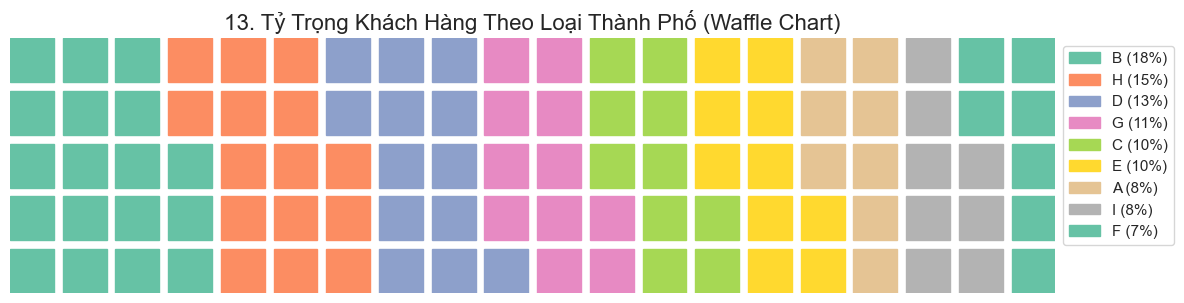

In [ ]:
city_counts = df['City_Type'].value_counts()
# Đưa về tỷ lệ phần trăm trên 100 ô
data_waffle = dict((city_counts / city_counts.sum() * 100).round().astype(int))

plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=data_waffle,
    colors=sns.color_palette("Set2", len(data_waffle)),
    labels=[f"{k} ({v}%)" for k, v in data_waffle.items()],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(12, 6),
    title={'label': '13. Tỷ Trọng Khách Hàng Theo Loại Thành Phố (Waffle Chart)', 'fontsize': 16}
)
plt.show()


#### Biểu đồ 14: Bar Chart - Phân bổ Mức thu nhập (Income)
- **Tại sao sử dụng:** Biểu diễn các hạng mục thu nhập (từ mức 0 đến mức 6) bằng Bar Chart giúp thấy rõ mức sống phổ biến của người bệnh.
- **Ý nghĩa & Kết luận:** Giúp định giá các dịch vụ/vật tư y tế trong trại cho phù hợp với khả năng chi trả của phần đông.

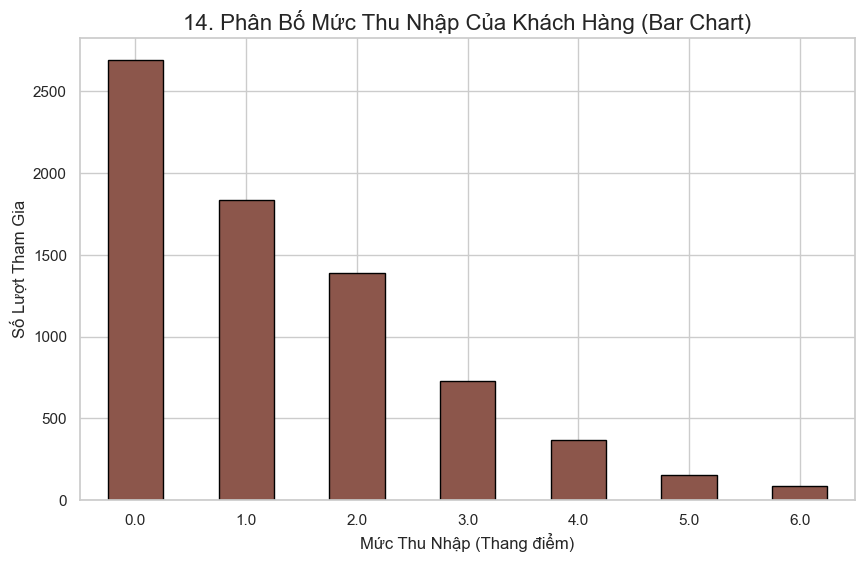

In [ ]:
income_counts = df['Income'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
income_counts.plot(kind='bar', color='#8c564b', edgecolor='black')
plt.title('14. Phân Bố Mức Thu Nhập Của Khách Hàng (Bar Chart)', fontsize=16)
plt.xlabel('Mức Thu Nhập (Thang điểm)')
plt.ylabel('Số Lượt Tham Gia')
plt.xticks(rotation=0)
plt.show()


#### Biểu đồ 15: Scatter Plot - Quan hệ giữa Độ tuổi và Thu nhập
- **Tại sao sử dụng:** Biểu đồ phân tán truyền thống (Scatter Plot) hiển thị 2 biến số định lượng để tìm kiếm bất kỳ mô hình phân cụm hoặc ngoại lai nào.
- **Ý nghĩa & Kết luận:** Kiểm tra xem người có thu nhập cao thường rơi vào độ tuổi nào để cá nhân hóa chiến dịch quảng cáo.

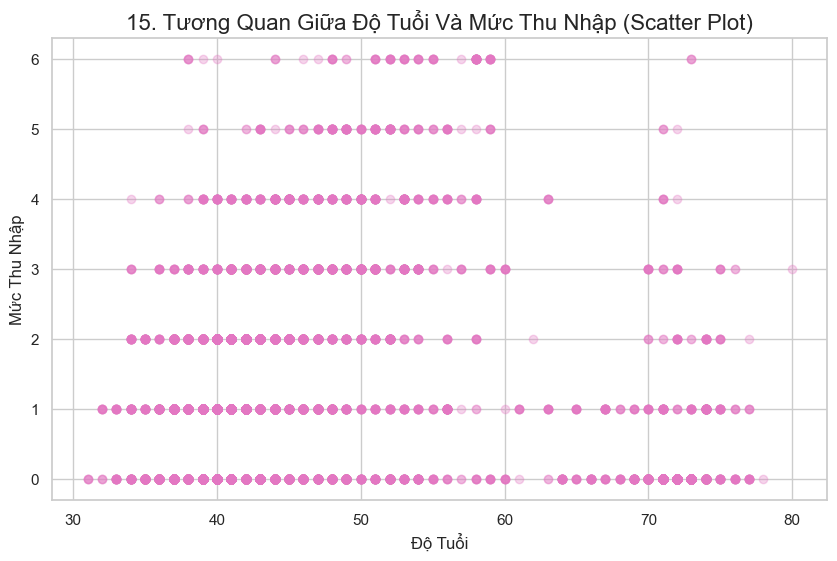

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Income'], alpha=0.3, color='#e377c2')
plt.title('15. Tương Quan Giữa Độ Tuổi Và Mức Thu Nhập (Scatter Plot)', fontsize=16)
plt.xlabel('Độ Tuổi')
plt.ylabel('Mức Thu Nhập')
plt.show()


---
> **KẾT LUẬN CÂU HỎI 4:** 
> - Chân dung khách hàng mục tiêu: Độ tuổi trung niên và cao niên (**40-65 tuổi**), sinh sống tại các **đô thị loại H**, có mức thu nhập trung bình (thang điểm 0-2).
> - Ngành nghề phổ biến nhất của họ là **Technology và BFSI**, cho thấy đây là tệp khách hàng có kiến thức và tiếp cận công nghệ tốt.


---
# TỔNG KẾT VÀ TRẢ LỜI CÂU HỎI CHÍNH

**Câu hỏi:** *"Đặc điểm của bệnh nhân tham gia và làm sao để tối ưu hóa chiến dịch?"*

**Trả lời:**
Dựa trên 15 biểu đồ phân tích, chúng ta có thể khẳng định khách hàng trọng tâm là nhóm **40-65 tuổi**, đến từ các đô thị lớn, làm việc trong các ngành công nghiệp hiện đại và có thói quen sử dụng MXH.

**Đề xuất chiến lược (Insights):**
1. **Kênh truyền thông:** Tập trung ngân sách quảng cáo vào **Facebook** và **LinkedIn** với thông điệp nhắm đúng độ tuổi trung niên.
2. **Sản phẩm/Dịch vụ:** Ưu tiên các loại trại thuộc danh mục **Category 1 (First)** và các tổ hợp **Category 2** đã xác định là "điểm nóng" trong Bubble Plot.
3. **Vận hành:** Tổ chức trại với thời lượng từ **3-7 ngày** để đạt hiệu suất tham gia tối ưu trên mỗi đơn vị chi phí.
